<a href="https://colab.research.google.com/github/Sharmika-18/Task-2/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import files
uploaded=files.upload();

Saving Tweets.csv to Tweets (1).csv


**Sentiment Analysis**

In [10]:
import pandas as pd

df = pd.read_csv("Tweets.csv")

print(df['airline_sentiment'].value_counts())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


**Natural Language Processing (Text Preprocessing)**

In [11]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)  # remove special chars
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df['text'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


**Feature Engineering**

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_text'])
y = df['airline_sentiment']


**Machine Learning Models**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Model 1: Naive Bayes**

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    negative       0.73      0.98      0.84      1889
     neutral       0.73      0.25      0.37       580
    positive       0.87      0.37      0.51       459

    accuracy                           0.74      2928
   macro avg       0.78      0.53      0.57      2928
weighted avg       0.75      0.74      0.69      2928



**Model 2: Logistic Regression**

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.67      0.47      0.55       580
    positive       0.80      0.62      0.70       459

    accuracy                           0.80      2928
   macro avg       0.76      0.68      0.71      2928
weighted avg       0.79      0.80      0.78      2928



**Model 3: Support Vector Machine**

In [16]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

    negative       0.84      0.91      0.87      1889
     neutral       0.63      0.52      0.57       580
    positive       0.75      0.68      0.71       459

    accuracy                           0.80      2928
   macro avg       0.74      0.70      0.72      2928
weighted avg       0.79      0.80      0.79      2928



**Sentiment Distribution**

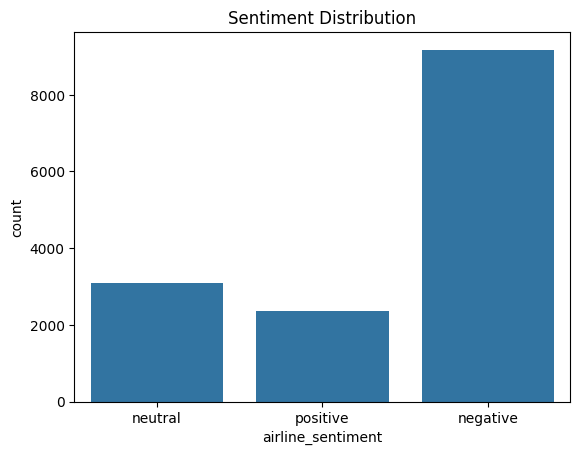

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='airline_sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


**Sentiment by Airline**

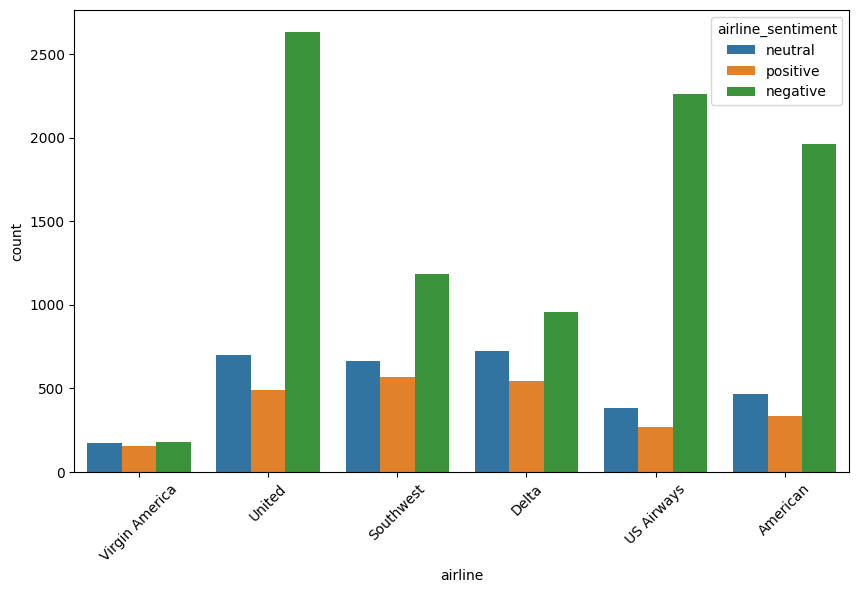

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x='airline', hue='airline_sentiment', data=df)
plt.xticks(rotation=45)
plt.show()


**Most Common Negative Reasons**

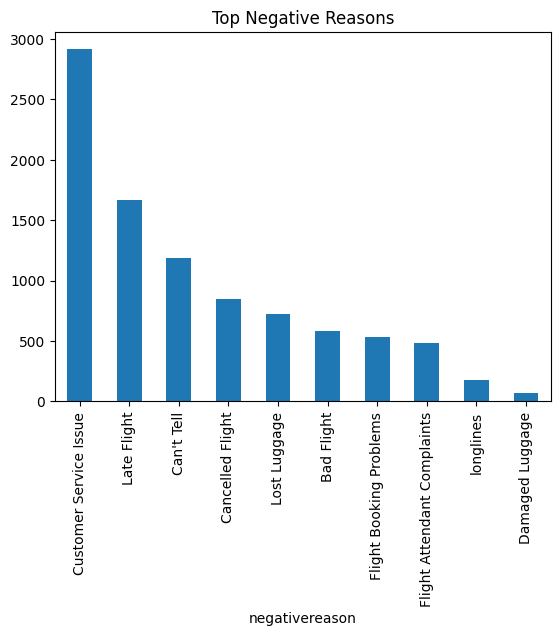

In [19]:
df[df['airline_sentiment']=="negative"]['negativereason'].value_counts().plot(kind='bar')
plt.title("Top Negative Reasons")
plt.show()

In [22]:
while True:

    user_input = input("Enter a tweet (or type exit): ")

    if user_input.lower() == "exit":
        break

    # Clean text
    cleaned = clean_text(user_input)

    # Convert to vector
    vector = vectorizer.transform([cleaned])

    # Predict sentiment using the Logistic Regression model (lr)
    prediction = lr.predict(vector)

    print("Predicted Sentiment:", prediction[0])

Enter a tweet (or type exit): This airline service is amazing
Predicted Sentiment: positive
Enter a tweet (or type exit): Exit
